# 02 — LangGraph Basics
**Study Notebook 2 of 3 · Estimated time: 30 minutes**

By the end of this notebook you will:
- Build the smallest possible LangGraph graph
- Add a **real, interactive** human approval gate — the graph pauses and waits for you to type a decision
- Add conditional routing on top of it, so only some cases even need a human
- Visualise the graph structure
- See the same shapes applied to the actual demo project: the FOSS Contribution Matchmaker

> **Prereq:** No API key needed for this notebook — LangGraph is pure Python orchestration.

---
## Step 0 — Install

In [1]:
!pip install -q langgraph

---
## Step 1 — The Basics

Every LangGraph graph has three ingredients:
1. **State** — a `TypedDict` that travels through every node
2. **Nodes** — Python functions that read and update the state
3. **Edges** — connections that define what runs next

We'll build this up in three small pieces: **1.1** the smallest graph that works, **1.2** a real
human-in-the-loop pause, **1.3** conditional routing on top of it.

### 1.1 — The Smallest Graph

One node, one edge. Just enough to see state flow through a graph.

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

class GreetState(TypedDict):
    name: str
    message: str

def greet_node(state: GreetState) -> dict:
    return {"message": f"Hello, {state['name']}!"}

builder = StateGraph(GreetState)
builder.add_node("greet", greet_node)
builder.set_entry_point("greet")
builder.add_edge("greet", END)

graph = builder.compile()
print(graph.invoke({"name": "Ajmal", "message": ""}))

{'name': 'Ajmal', 'message': 'Hello, Ajmal!'}


That's it — a `TypedDict` state, one node function, one edge to `END`. Everything else in this
notebook is this same shape, just with more nodes and a decision or two.

### 1.2 — Human in the Loop

The single most useful LangGraph pattern is also easy to build: **pause, show a human something, wait
for a real decision, then continue.**

Here, the state is just a request and a yes/no decision.

In [3]:
from langgraph.checkpoint.memory import MemorySaver

class ApprovalState(TypedDict):
    request: str
    approved: bool
    outcome: str

def request_node(state: ApprovalState) -> dict:
    print(f"[request] {state['request']}")
    print(">>> PAUSED -- waiting for a human decision <<<")
    return {}

def outcome_node(state: ApprovalState) -> dict:
    if state["approved"]:
        print("[outcome] Approved.")
        return {"outcome": "approved"}
    print("[outcome] Declined.")
    return {"outcome": "declined"}

checkpointer = MemorySaver()
approval_builder = StateGraph(ApprovalState)
approval_builder.add_node("request", request_node)
approval_builder.add_node("outcome", outcome_node)
approval_builder.set_entry_point("request")
approval_builder.add_edge("request", "outcome")
approval_builder.add_edge("outcome", END)

# interrupt_before pauses the graph BEFORE running "outcome"
gate = approval_builder.compile(checkpointer=checkpointer, interrupt_before=["outcome"])

config = {"configurable": {"thread_id": "approval-1"}}
initial_state = {"request": "Deploy v2.0 to production", "approved": False, "outcome": ""}

# Run until the gate -- this stops right before "outcome"
for _ in gate.stream(initial_state, config):
    pass

[request] Deploy v2.0 to production
>>> PAUSED -- waiting for a human decision <<<


In [4]:
# ─── This is the real, dynamic part ───────────────────────────────────────────
# The graph is paused. Nothing has happened yet. Type your own decision below.
decision = input("Approve or decline? (yes/no): ").strip().lower()
approved = decision in ("yes", "y")

# Inject your live decision into the paused graph's state, then resume it
gate.update_state(config, {"approved": approved})
for _ in gate.stream(None, config):
    pass

print(f"\nOutcome: {gate.get_state(config).values['outcome']}")

Approve or decline? (yes/no): yes
[outcome] Approved.

Outcome: approved


**What made this dynamic:** the second cell didn't run until *you* ran it, and the graph didn't move
past `request` until you typed a real answer at the `input()` prompt. Run the two cells again and answer
`no` this time — `outcome` becomes `"declined"`. Nothing here is a hardcoded, scripted decision.

### 1.3 — Conditional Routing: Not Everything Needs a Human

Pausing for approval is powerful, but you don't want a human reviewing *every* request. Small,
low-risk ones can be handled automatically; only the ones that matter get escalated.

We'll route by amount: small requests auto-approve, large ones go through the same human gate
from 1.2.

In [5]:
from typing import Literal

class ExpenseState(TypedDict):
    request: str
    amount: float
    approved: bool
    outcome: str

def auto_approve_node(state: ExpenseState) -> dict:
    print(f"[auto_approve] {state['request']} (₹{state['amount']}) -- below threshold, no review needed.")
    return {"outcome": "auto-approved"}

def request_review_node(state: ExpenseState) -> dict:
    print(f"[request_review] {state['request']} (₹{state['amount']}) -- needs a human.")
    print(">>> PAUSED -- waiting for a human decision <<<")
    return {}

def decide_node(state: ExpenseState) -> dict:
    if state["approved"]:
        print("[decide] Approved.")
        return {"outcome": "approved"}
    print("[decide] Declined.")
    return {"outcome": "declined"}

def route_by_amount(state: ExpenseState) -> Literal["auto_approve", "request_review"]:
    return "auto_approve" if state["amount"] < 100 else "request_review"

expense_builder = StateGraph(ExpenseState)
expense_builder.add_node("auto_approve", auto_approve_node)
expense_builder.add_node("request_review", request_review_node)
expense_builder.add_node("decide", decide_node)

# A conditional entry point routes straight from the graph's start
expense_builder.set_conditional_entry_point(route_by_amount)
expense_builder.add_edge("auto_approve", END)
expense_builder.add_edge("request_review", "decide")
expense_builder.add_edge("decide", END)

expense_gate = expense_builder.compile(checkpointer=MemorySaver(), interrupt_before=["decide"])

In [6]:
# Small amount -- routed straight to auto_approve, no pause
config_small = {"configurable": {"thread_id": "expense-small"}}
result = expense_gate.invoke(
    {"request": "Team lunch", "amount": 40, "approved": False, "outcome": ""}, config_small)
print("Small request outcome:", result["outcome"])

# Large amount -- pauses at the same human gate from 1.2
print()
config_large = {"configurable": {"thread_id": "expense-large"}}
for _ in expense_gate.stream(
    {"request": "New laptop", "amount": 1200, "approved": False, "outcome": ""}, config_large):
    pass

decision = input("Approve or decline the laptop purchase? (yes/no): ").strip().lower()
approved = decision in ("yes", "y")
expense_gate.update_state(config_large, {"approved": approved})
for _ in expense_gate.stream(None, config_large):
    pass
print(f"\nLarge request outcome: {expense_gate.get_state(config_large).values['outcome']}")

[auto_approve] Team lunch (₹40) -- below threshold, no review needed.
Small request outcome: auto-approved

[request_review] New laptop (₹1200) -- needs a human.
>>> PAUSED -- waiting for a human decision <<<
Approve or decline the laptop purchase? (yes/no): yes
[decide] Approved.

Large request outcome: approved


Notice the small request never paused at all — `route_by_amount` sent it straight to
`auto_approve` and `END`. Only the large request reached the human gate. That combination — **route
automatically where you can, pause for a human only where it matters** — is the core idea behind
production approval flows.

### 1.4 — Visualise the Graph

In [7]:
!pip install -q grandalf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00


In [8]:
# ASCII graph (works everywhere without graphviz)
print(expense_gate.get_graph().draw_ascii())

               +-----------+                
               | __start__ |                
               +-----------+                
               ..          ...              
             ..               .             
           ..                  ...          
+----------------+                .         
| request_review |                .         
+----------------+                .         
         *                        .         
         *                        .         
         *                        .         
    +--------+            +--------------+  
    | decide |            | auto_approve |  
    +--------+*           +--------------+  
               **          ***              
                 **       *                 
                   **   **                  
                +---------+                 
                | __end__ |                 
                +---------+                 


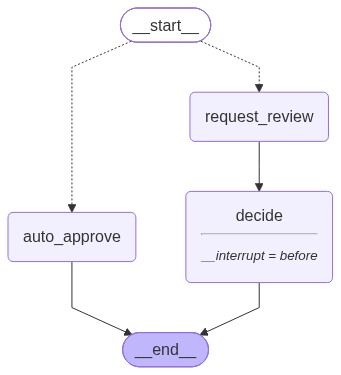

In [12]:
from IPython.display import Image, display
display(Image(expense_gate.get_graph().draw_mermaid_png()))


---
## Step 2 — Real-World Example: The FOSS Contribution Matchmaker (Preview)

Everything above is the same shape used in the actual demo project. Here's a small, offline preview of
`analyze_profile_node` from `foss_demo.ipynb` — fetch a GitHub profile, then summarise it.

In [10]:
from collections import Counter

class ProfileState(TypedDict):
    username: str
    repo_languages: list
    top_language: str

# Mocked here to keep this notebook offline and API-key-free.
# The final demo calls the real GitHub API for this.
MOCK_PROFILES = {
    "torvalds":    ["C", "C", "Shell", "C"],
    "gvanrossum":  ["Python", "Python", "C", "Python"],
}

def fetch_profile_node(state: ProfileState) -> dict:
    """Fetch (mocked) repo languages for a username."""
    languages = MOCK_PROFILES.get(state["username"], ["Python"])
    print(f"[fetch_profile] {state['username']} -> {languages}")
    return {"repo_languages": languages}

def summarize_node(state: ProfileState) -> dict:
    """Pick the most common language."""
    top = Counter(state["repo_languages"]).most_common(1)[0][0]
    print(f"[summarize] top language = {top}")
    return {"top_language": top}

profile_builder = StateGraph(ProfileState)
profile_builder.add_node("fetch_profile", fetch_profile_node)
profile_builder.add_node("summarize", summarize_node)
profile_builder.set_entry_point("fetch_profile")
profile_builder.add_edge("fetch_profile", "summarize")
profile_builder.add_edge("summarize", END)

profile_graph = profile_builder.compile()
result = profile_graph.invoke({"username": "torvalds", "repo_languages": [], "top_language": ""})
print(f"\nFinal state: {result}")

[fetch_profile] torvalds -> ['C', 'C', 'Shell', 'C']
[summarize] top language = C

Final state: {'username': 'torvalds', 'repo_languages': ['C', 'C', 'Shell', 'C'], 'top_language': 'C'}


**Where these patterns land in the real demo:**

| What you just built | Becomes, in `foss_demo.ipynb` |
|---|---|
| `fetch_profile` + `summarize` | `analyze_profile_node` (merged into one node — parsing is trivial enough not to need its own step) |
| Conditional routing by amount | `ComplexityRaterAgent` routing repos by stars/experience |
| The human-in-the-loop gate | Where a maintainer would review an AI-drafted onboarding guide before anything gets published |

Small enough to be two nodes here; small enough to be *one* node there. That's a judgment call, not a
rule — merge when a step is trivial, keep separate when a step does meaningfully different work.

---
## Exercise — Add a Third Branch

Extend `expense_gate` (Step 1.3) with an `auto_decline` branch: amounts over ₹50,000 are clearly out of
policy and should be declined automatically, without even reaching a human.

In [11]:
# Your solution here
def auto_decline_node(state):
    print(f"[auto_decline] {state['request']} (₹{state['amount']}) -- over policy limit, declined automatically.")
    return {"outcome": "auto-declined"}

# TODO:
#  1. Update route_by_amount to return "auto_decline" when amount > 50000
#  2. Add the node and an edge to END, the same way auto_approve is wired

---
## Summary

| Concept | LangGraph tool |
|---------|----------------|
| Typed state dict | `TypedDict` |
| Graph builder | `StateGraph` |
| Linear flow | `add_edge(A, B)` |
| Conditional routing | `set_conditional_entry_point(router_fn)` |
| Human gate (pause) | `interrupt_before=["node_name"]` + `MemorySaver` |
| Real human input | `input()` inside the resume cell — not a hardcoded value |
| Resume after gate | `update_state()` then `stream(None, config)` |

**Next:** `03_a2a_basics.ipynb` — learn the A2A protocol and wire 3 specialist agents into LangGraph
to build the full FOSS Contribution Matchmaker.